In [1]:
# import the usual suspects
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from src.cf_generator_dice import DiceCFGenerator
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, roc_auc_score,balanced_accuracy_score

In [2]:
from seaborn import cm

In [3]:
import importlib
import src.utils as utl
importlib.reload(utl)

<module 'src.utils' from '/home/vbonsignori/L2loRe/src/utils.py'>

In [4]:
import src.fancy_plots as fplt
importlib.reload(fplt)


<module 'src.fancy_plots' from '/home/vbonsignori/L2loRe/src/fancy_plots.py'>

In [100]:
# let's find the different files we need
config = utl.load_config('config.yaml')
cf_results = config['paths']['counterfactuals']


dt_name = "adult48k"
dt_name = "german_credit"
dt_name = "toy_dataset"
dt_name = 'breast_cancer'
cf_method = ["dice","ils",'lore','growing_spheres'][-1]



name_dataset = {"german_credit": "German Credit",
                "toy_dataset":"Toy Dataset",
                "adult48k":"Adult",
                "breast_cancer": "Breast Cancer",
                }[dt_name]
cf_results

'counterfactuals/'

In [101]:
data_processor = DataProcessor(config=config)
splits = data_processor.load_splits(dt_name)

Loaded feature names from data/processed/breast_cancer/feature_names.csv
Loaded X_train from data/processed/breast_cancer/X_train.npz
Loaded y_train from data/processed/breast_cancer/y_train.npz
Loaded X_test from data/processed/breast_cancer/X_test.npz
Loaded y_test from data/processed/breast_cancer/y_test.npz
Loaded X_calibration from data/processed/breast_cancer/X_calibration.npz
Loaded y_calibration from data/processed/breast_cancer/y_calibration.npz


In [102]:

model_trainer = ModelTrainer(config)
models = model_trainer.train_model(X_train=splits['X_train'], 
                                    y_train=splits['y_train'], 
                                    X_test=splits['X_test'], 
                                    y_test=splits['y_test'],
                                    dataset_name=dt_name)
print(models.keys())

Processing random_forest for breast_cancer
Loaded random_forest model from models/breast_cancer/random_forest.pkl
Loaded existing random_forest model
Processing mlp for breast_cancer
Loaded mlp model from models/breast_cancer/mlp.pkl
Loaded existing mlp model
Processing xgboost for breast_cancer
Loaded xgboost model from models/breast_cancer/xgboost.pkl
Loaded existing xgboost model
Processing lgbm for breast_cancer
Loaded lgbm model from models/breast_cancer/lgbm.pkl
Loaded existing lgbm model
dict_keys(['random_forest', 'mlp', 'xgboost', 'lgbm'])


In [103]:
for k in models.keys():
    roc = roc_auc_score(splits['y_test'], models[k].predict_proba(splits['X_test'])[:,1]).round(2)
    print(f"Model {k} ROC AUC: {roc}")
    acc = accuracy_score(splits['y_test'], models[k].predict(splits['X_test'])).round(2)
    print(f"Model {k} Accuracy: {acc}")
    f1_ = f1_score(splits['y_test'], models[k].predict(splits['X_test']), average='weighted').round(2)
    print(f"Model {k} F1 Score: {f1_}")
    balanced_accuracy = balanced_accuracy_score(splits['y_test'], models[k].predict(splits['X_test'])).round(2)
    print(f"Model {k} Balanced Accuracy: {balanced_accuracy}")
    #print(classification_report(splits['y_test'], models[k].predict(splits['X_test'])))
    utl.plot_confusion_ascii(splits['y_test'], models[k].predict(splits['X_test']),ascii_set=5)
    # print(confusion_matrix(splits['y_test'], models[k].predict(splits['X_test']))
    print()
    

Model random_forest ROC AUC: 0.99
Model random_forest Accuracy: 0.96
Model random_forest F1 Score: 0.96
Model random_forest Balanced Accuracy: 0.95
■ 
 █

Model mlp ROC AUC: 0.99
Model mlp Accuracy: 0.98
Model mlp F1 Score: 0.98
Model mlp Balanced Accuracy: 0.97
■ 
 █

Model xgboost ROC AUC: 0.99
Model xgboost Accuracy: 0.98
Model xgboost F1 Score: 0.98
Model xgboost Balanced Accuracy: 0.97
■ 
 █

Model lgbm ROC AUC: 0.99
Model lgbm Accuracy: 0.97
Model lgbm F1 Score: 0.97
Model lgbm Balanced Accuracy: 0.96
■ 
 █



In [104]:
# import the fancy for bar chart tdqm
from  tqdm.notebook import tqdm,tnrange, tqdm_notebook
import time




In [105]:
np.random.randint(0,7), np.random.rand()*7

(0, 1.5797344690197743)

In [106]:

                 
import pickle

#with open("debug/ranking_new_t.pkl", "rb") as f:
#    all_ranking_list_mean, all_ranking_list_std, all_ranking_list_min, all_ranking_list_max, all_probabs,corrects = pickle.load(f)


### The distances took into account

In [107]:
from src.distances import get_distances
metrics = ["l0", "l1", "l2", "inf", "-inf", "sqeuclidean", "mae", "cosine", "correlation", "chebyshev", "minkowski", "canberra", "braycurtis", "hamming", "jaccard", "wasserstein", "spearman", "kendall", "centered_l2", "centered_cosine"]

In [108]:
'''
X = splits['X_test'].values[:10]

x = splits['X_test'].values[0]

print("Distance examples:")
for metric in metrics:
        distances = get_distances(X,x, policy=metric)
        #print(f"{metric} : {[f'{d:.2f}' for d in distances]}")
        plt.plot(distances, label=metric)
plt.legend()
plt.show()
'''

'\nX = splits[\'X_test\'].values[:10]\n\nx = splits[\'X_test\'].values[0]\n\nprint("Distance examples:")\nfor metric in metrics:\n        distances = get_distances(X,x, policy=metric)\n        #print(f"{metric} : {[f\'{d:.2f}\' for d in distances]}")\n        plt.plot(distances, label=metric)\nplt.legend()\nplt.show()\n'

In [109]:
all_stats = {
    model_name: {
        'distances': {
            metric: {
                'min': [],   # One value per sample
                'max': [],   # One value per sample
                'mean': [],  # One value per sample, equal to min or max if only one value
                'std': [],   # One value per sample
            } for metric in metrics
        },
        'probabs': [],      # Keep the original probabs
        'corrects': [],      # Keep original # corrects
        'mean_conf': []  # One value per sample
        
    } for model_name in models.keys()
}




In [110]:
all_stats_test = {
    model_name: {
        'distances': {
            metric: {
                'min': [],   # One value per sample
                'max': [],   # One value per sample
                'mean': [],  # One value per sample, equal to min or max if only one value
                'std': [],   # One value per sample
            } for metric in metrics
        },
        'probabs': [],      # Keep the original probabs
        'corrects': [],      # Keep original # corrects
        'mean_conf': []  # One value per sample
        
    } for model_name in models.keys()
}


## Scaled features?

In [111]:
scaled = False


In [112]:
fname = os.path.join(cf_method,dt_name+f"_ranking{'_scaled' if scaled else ''}.pkl")
if utl.check_file_exists(fname):
    with open(fname, "rb") as f:
        all_stats = pickle.load(f)
        print("Loaded",fname)
else:
    print("!"*6,fname, "not found")
fname_test = os.path.join(cf_method,dt_name+f"_ranking_test{'_scaled' if scaled else ''}.pkl")
if utl.check_file_exists(fname_test):
    with open(fname_test,'rb') as f:
        all_stats_test = pickle.load(f)
        print("Loaded",fname_test)
else:
    print("!"*6,fname_test, "not found")


!!!!!! growing_spheres/breast_cancer_ranking.pkl not found
!!!!!! growing_spheres/breast_cancer_ranking_test.pkl not found


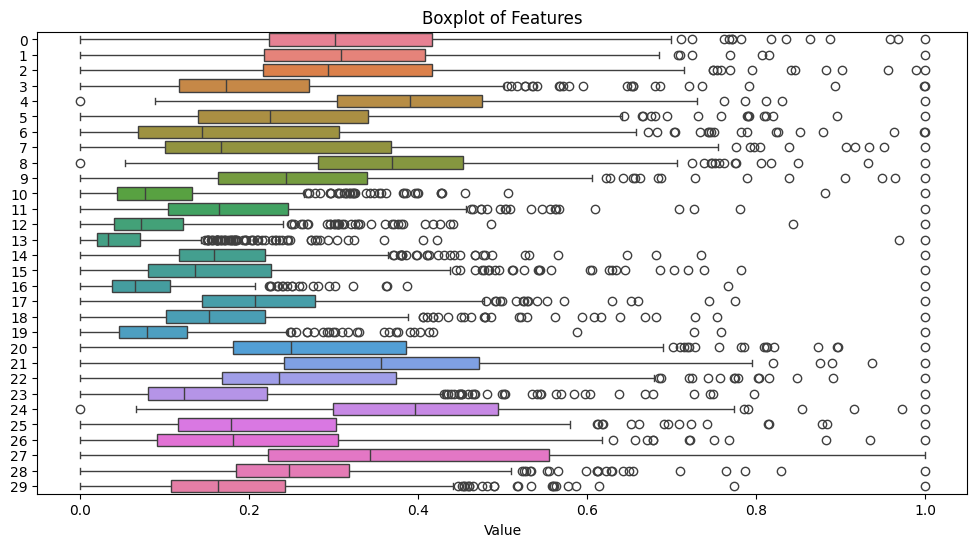

In [113]:
# plot the boxplot of the features
plt.figure(figsize=(12, 6))
sns.boxplot(data=np.vstack([splits["X_train"], splits["X_calibration"], splits["X_test"]]), orient="h")

plt.xlabel('Value')
plt.title('Boxplot of Features')
plt.show()


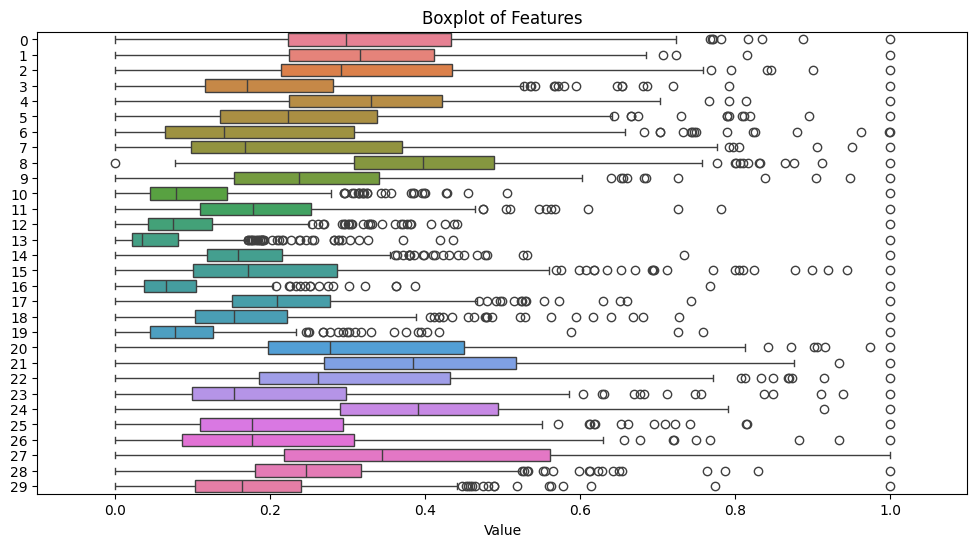

In [114]:
# Stack all splits as numpy arrays
X_all = np.vstack([
    splits["X_train"].values,
    splits["X_calibration"].values,
])
plot_lim = X_all.min(axis=0).min(), X_all.max(axis=0).max()
plot_lim = (plot_lim[0] - 0.1, plot_lim[1] + 0.1)
curr_min = X_all.min(0)
curr_max = X_all.max(0)

def normalize(x):
    # normalize the features of the dataframe or numpy array to [0,1]
    return (x - curr_min) / (curr_max - curr_min)

plt.figure(figsize=(12, 6))
sns.boxplot(data=normalize(X_all), orient="h")
plt.xlabel('Value')
plt.xlim(plot_lim)
plt.title('Boxplot of Features')
plt.show()

In [115]:
def check_res(stats_dict = all_stats,k="mlp"):
    """this function return True if the distances related to the model k are already computed"""
    # try if the list containing the mean dists has length > 0
    try:
        print("("+str(len(stats_dict[k]['distances']['l2']['mean'])),"elements computed)")
        return len(stats_dict[k]['distances']['l2']['mean']) >= 200
    except Exception as e:
        print(e)
        return False
for k in models.keys():
    print(k, "computed?",check_res(stats_dict = all_stats,k=k))
    
    print("\t","test?",check_res(stats_dict=all_stats_test,k=k))

(0 elements computed)
random_forest computed? False
(0 elements computed)
	 test? False
(0 elements computed)
mlp computed? False
(0 elements computed)
	 test? False
(0 elements computed)
xgboost computed? False
(0 elements computed)
	 test? False
(0 elements computed)
lgbm computed? False
(0 elements computed)
	 test? False


In [132]:
compute_test = False

In [133]:
all_stats_tmp = all_stats_test if compute_test else all_stats
def select_test (x):return "test" in x if compute_test else ("test" not in x)

In [134]:
select_test("test"), select_test("train")

(False, True)

In [135]:
# do a fast check to see if the 
for k in models.keys():
    result_f = os.path.join("counterfactuals",k,dt_name)
    print(result_f)
    try:
        list_files = os.listdir(result_f)
        print("Number of files",len(list_files))
    except:
        print(result_f,"File not found")

counterfactuals/random_forest/breast_cancer
Number of files 8
counterfactuals/mlp/breast_cancer
Number of files 8
counterfactuals/xgboost/breast_cancer
Number of files 8
counterfactuals/lgbm/breast_cancer
Number of files 8


## Compute the distances 
Counterfactual should be already present

In [136]:
cfs["cfs"][i]["counterfactuals"].std(axis=0)

0         0.099696
1         0.126818
2         0.000000
3         0.000000
4         0.046091
5         0.000000
6         0.000000
7         0.147028
8         0.000000
9         0.030974
10        0.099187
11        0.050199
12        0.060138
13        0.123327
14        0.000000
15        0.058371
16        0.000000
17        0.000000
18        0.000000
19        0.024942
20        0.000000
21        0.110110
22        0.077154
23        0.000000
24        0.091051
25        0.000000
26        0.081602
27        0.138745
28        0.023391
29        0.000000
target    0.000000
dtype: float64

In [137]:
"growing_spheres",cf_method

('growing_spheres', 'growing_spheres')

In [138]:
start = time.time()
for jj,k in enumerate(tqdm(models.keys())):
    not_found = 0
    # load the counterfactuals
    result_folder_path = os.path.join(cf_results,
                        k,
                        dt_name)
    print("looking into the folder ",result_folder_path)
    results = os.listdir(result_folder_path)
    # remove the ones that are not npz
    results = [r for r in results if r.endswith(".npz") and cf_method in r]
    # remove those that contains "test" in the name
    results = [r for r in results if select_test(r)]
    # take the most recent using os.path.getmtime
    results = sorted(results,key=lambda x: os.path.getmtime(os.path.join(result_folder_path,x)),reverse=True)
    print("I found",len(results),"files")
    if len(results) > 1:
        for i,f in enumerate(results):
            print(str(i)+")",f)
        # i = input()
        # take the most recent 
        i = 0
        if isinstance(i,int):
            results = [results[i]]
        else:
            results = [results[-1]]
    print("for model",k,"using file",results[-1])

    r = results[-1]
    
    print("checking",r)
    # load the counterfactuals most recent using nupy
    cfs = np.load(os.path.join(result_folder_path, r),allow_pickle=True)#results[0]), allow_pickle=True)
    # cfs is a dictionary with keys "cfs" as the only key (it's an npz file). The value of "cfs" is a np array of dictionaries. The keys of the dictionaries are:, instace_idx (the index of the instance in the calibration set), original_instance (the original class of the instance), true_class (the true class of the instance)
    print(cfs["cfs"].shape[0])
    if check_res(stats_dict=all_stats_tmp,k=k):
        print("Already computed for model",k,end=" elements:")
        print(len(all_stats_tmp[k]['distances']['l2']['mean']))
        continue
    else:
        print("Not computed for model",k,"computing...")
        # reset the stats for the model
        all_stats_tmp[k] = {
            'distances': {metric: {'min': [],'max': [],'mean': [],'std': [], } for metric in metrics},
            'probabs': [],'corrects': [],'mean_conf': []
        }

    probabs, corrects, confs = [], [], []
    
    for i in tnrange(cfs["cfs"].shape[0]):
        ## let's see the output for the original instance
        ## and check if the model is predicting the class (even to check what true_class is)
        ## then we can check the counterfactuals and see if the model is predicting the opposite class
        ## and if it aligns with the "target" attribute of the counterfactuals
        original_instance = cfs["cfs"][i]["original_instance"]
        # original instance is not anymore the right one sadly... 
        # therefore we get the original instance from the dataset itself by using the "compute_test" flag and the  instance_idx attribute
        original_instance = splits[('X_test' if  compute_test else 'X_calibration')].iloc[cfs["cfs"][i]["instance_idx"]].values.reshape(1,-1)
        original_class = cfs["cfs"][i]["true_class"].values
        
        #true_cf = cfs["cfs"][i]["counterfactuals"].target.values
        pred = models[k].predict(original_instance)
        pred_prob = models[k].predict_proba(original_instance)[0]
        correct = original_class == pred
        #print(pred,original_class)
        if cf_method != "ils":
            good_cfs = cfs["cfs"][i]["counterfactuals"].values[:,:-1]

            pred_cfs = cfs["cfs"][i]["counterfactuals"].values[:,-1]
            if len (good_cfs) > 0:
                mean_confidences_cfs = models[k].predict_proba(good_cfs).mean(axis=0)
            else:
                mean_confidences_cfs = np.array([np.nan,np.nan])
        else:
            good_cfs = cfs["cfs"][i]["counterfactuals"].values
            if len (good_cfs) > 0:
                pred_good_cfs = models[k].predict_proba(good_cfs)
                pred_cfs = pred_good_cfs.argmax(axis=1)
                mean_confidences_cfs = pred_good_cfs.mean(axis=0)
            else:
                pred_good_cfs

                mean_confidences_cfs = np.array([np.nan,np.nan])
        #    
        #good_cfs = good_cfs[true_cf != pred]
        true_cf = np.ones(len(good_cfs))#true_cf[true_cf != pred]

        if normalize:
            if len(good_cfs) > 0:
                good_cfs = normalize(good_cfs)
                original_instance = normalize(original_instance)
        for metric in metrics:
            if len(good_cfs) == 0:
                distancies = np.array([np.inf])
                print("NOT FOUND COUNTERFACTUALS FOR SAMPLE",i)
                not_found+=1
            else:
                if (abs(pred-pred_cfs).mean() != 1).all():
                    print("The counterfactuals should have class != "+str(pred_cfs[:10]
                                 )+" are not aligned with the target"+str(pred.mean()))
                    distancies = np.array([np.inf])
                else:
                    distancies = get_distances(good_cfs, 
                                           original_instance,
                                        policy=metric)
                    
            
            all_stats_tmp[k]['distances'][metric]['min'].append(distancies.min(axis=0))
            all_stats_tmp[k]['distances'][metric]['max'].append(distancies.max(axis=0))
            all_stats_tmp[k]['distances'][metric]['mean'].append(distancies.mean(axis=0))
            all_stats_tmp[k]['distances'][metric]['std'].append(distancies.std(axis=0))
            
        probabs.append(pred_prob)
        corrects.append(correct)
        confs.append(mean_confidences_cfs)
        # print(distancies)
        #if i / 4 < 1:
        #   sns.kdeplot(distancies,cumulative=False,label=str(i)+" "+str(len(distancies))+ " counterfactuals "+k,ax=axs[i])
    all_stats_tmp[k]['probabs'] = probabs
    all_stats_tmp[k]['corrects'] = corrects
    all_stats_tmp[k]['mean_conf'] = confs
    print("For the model ",k,"not found",not_found,"counterfactuals")


  0%|          | 0/4 [00:00<?, ?it/s]

looking into the folder  counterfactuals/random_forest/breast_cancer
I found 1 files
for model random_forest using file cf_results_growing_spheres_growing_spheres_calibration_20251217_180821.npz
checking cf_results_growing_spheres_growing_spheres_calibration_20251217_180821.npz
115
(0 elements computed)
Not computed for model random_forest computing...


  0%|          | 0/115 [00:00<?, ?it/s]

For the model  random_forest not found 0 counterfactuals
looking into the folder  counterfactuals/mlp/breast_cancer
I found 1 files
for model mlp using file cf_results_growing_spheres_growing_spheres_calibration_20251217_175248.npz
checking cf_results_growing_spheres_growing_spheres_calibration_20251217_175248.npz
115
(0 elements computed)
Not computed for model mlp computing...


  0%|          | 0/115 [00:00<?, ?it/s]

For the model  mlp not found 0 counterfactuals
looking into the folder  counterfactuals/xgboost/breast_cancer
I found 1 files
for model xgboost using file cf_results_growing_spheres_growing_spheres_calibration_20251217_191754.npz
checking cf_results_growing_spheres_growing_spheres_calibration_20251217_191754.npz
115
(0 elements computed)
Not computed for model xgboost computing...


  0%|          | 0/115 [00:00<?, ?it/s]

For the model  xgboost not found 0 counterfactuals
looking into the folder  counterfactuals/lgbm/breast_cancer
I found 1 files
for model lgbm using file cf_results_growing_spheres_growing_spheres_calibration_20251217_190408.npz
checking cf_results_growing_spheres_growing_spheres_calibration_20251217_190408.npz
115
(0 elements computed)
Not computed for model lgbm computing...


  0%|          | 0/115 [00:00<?, ?it/s]

For the model  lgbm not found 0 counterfactuals


In [139]:
'''from concurrent.futures import ThreadPoolExecutor
from tqdm.notebook import tqdm
import os
import numpy as np

def process_model(k):
    not_found = 0
    result_folder_path = os.path.join(cf_results, k, dt_name)
    results = os.listdir(result_folder_path)
    results = [r for r in results if r.endswith(".npz") and cf_method in r]
    results = [r for r in results if select_test(r)]
    results = sorted(results, key=lambda x: os.path.getmtime(os.path.join(result_folder_path, x)), reverse=True)

    if len(results) > 1:
        results = [results[0]]

    r = results[-1]
    cfs = np.load(os.path.join(result_folder_path, r), allow_pickle=True)

    if check_res(stats_dict=all_stats_tmp, k=k):
        return f"Already computed for model {k}"

    probabs, corrects, confs = [], [], []

    for i in range(cfs["cfs"].shape[0]):
        original_instance = splits[('X_test' if compute_test else 'X_calibration')].iloc[cfs["cfs"][i]["instance_idx"]].values.reshape(1, -1)
        original_class = cfs["cfs"][i]["true_class"].values
        pred = models[k].predict(original_instance)
        pred_prob = models[k].predict_proba(original_instance)[0]
        correct = original_class == pred
        good_cfs = cfs["cfs"][i]["counterfactuals"].values[:, :-1]
        pred_cfs = cfs["cfs"][i]["counterfactuals"].values[:, -1]

        if len(good_cfs) > 0:
            mean_confidences_cfs = models[k].predict_proba(good_cfs).mean(axis=0)
        else:
            mean_confidences_cfs = np.array([np.nan, np.nan])

        for metric in metrics:
            if len(good_cfs) == 0:
                distancies = np.array([np.inf])
                not_found += 1
            else:
                distancies = get_distances(good_cfs, cfs["cfs"][i]["original_instance"].values, policy=metric)

            all_stats_tmp[k]['distances'][metric]['min'].append(distancies.min(axis=0))
            all_stats_tmp[k]['distances'][metric]['max'].append(distancies.max(axis=0))
            all_stats_tmp[k]['distances'][metric]['mean'].append(distancies.mean(axis=0))
            all_stats_tmp[k]['distances'][metric]['std'].append(distancies.std(axis=0))

        probabs.append(pred_prob)
        corrects.append(correct)
        confs.append(mean_confidences_cfs)

    all_stats_tmp[k]['probabs'] = probabs
    all_stats_tmp[k]['corrects'] = corrects
    all_stats_tmp[k]['mean_conf'] = confs

    return f"For the model {k}, not found {not_found} counterfactuals"

# Parallelize the loop using ThreadPoolExecutor
with ThreadPoolExecutor() as executor:
    results = list(tqdm(executor.map(process_model, models.keys()), total=len(models.keys())))

# Print results
for res in results:
    print(res)'''

'from concurrent.futures import ThreadPoolExecutor\nfrom tqdm.notebook import tqdm\nimport os\nimport numpy as np\n\ndef process_model(k):\n    not_found = 0\n    result_folder_path = os.path.join(cf_results, k, dt_name)\n    results = os.listdir(result_folder_path)\n    results = [r for r in results if r.endswith(".npz") and cf_method in r]\n    results = [r for r in results if select_test(r)]\n    results = sorted(results, key=lambda x: os.path.getmtime(os.path.join(result_folder_path, x)), reverse=True)\n\n    if len(results) > 1:\n        results = [results[0]]\n\n    r = results[-1]\n    cfs = np.load(os.path.join(result_folder_path, r), allow_pickle=True)\n\n    if check_res(stats_dict=all_stats_tmp, k=k):\n        return f"Already computed for model {k}"\n\n    probabs, corrects, confs = [], [], []\n\n    for i in range(cfs["cfs"].shape[0]):\n        original_instance = splits[(\'X_test\' if compute_test else \'X_calibration\')].iloc[cfs["cfs"][i]["instance_idx"]].values.reshape

In [142]:
print("Ready?")

Ready?


In [143]:
fname,fname_test

('growing_spheres/breast_cancer_ranking.pkl',
 'growing_spheres/breast_cancer_ranking_test.pkl')

## Save files for the distances
if not already present

In [144]:
if compute_test:
    all_stats_test = all_stats_tmp
else:
    all_stats = all_stats_tmp
compute_test

False

In [145]:
max(all_stats_tmp[k]['distances']['l2']['max']),min(all_stats_tmp[k]['distances']['l2']['min'])

(1.3913489350364423, 0.0006527423954738598)

Checking cosine distances for random_forest max min value 6.1619283009406445e-09 max value 0.2824171859012665
Checking cosine distances for random_forest min min value 3.3434449653313436e-09 max value 0.13043814291374178
Checking cosine distances for random_forest mean min value 3.968689397948477e-09 max value 0.19154104719363257
0.9652173913043478
0.9647887323943662
True True
Checking cosine distances for mlp max min value 1.1718693460061047e-07 max value 0.14936419222363917
Checking cosine distances for mlp min min value 5.392397051107167e-08 max value 0.09260814154377472
Checking cosine distances for mlp mean min value 8.580891327121994e-08 max value 0.11743934533237876
0.9652173913043478
0.9788732394366197
True True
Checking cosine distances for xgboost max min value 4.189254854125579e-08 max value 0.22209715411249842
Checking cosine distances for xgboost min min value 2.323081615962508e-08 max value 0.10257413795826575
Checking cosine distances for xgboost mean min value 2.8628796

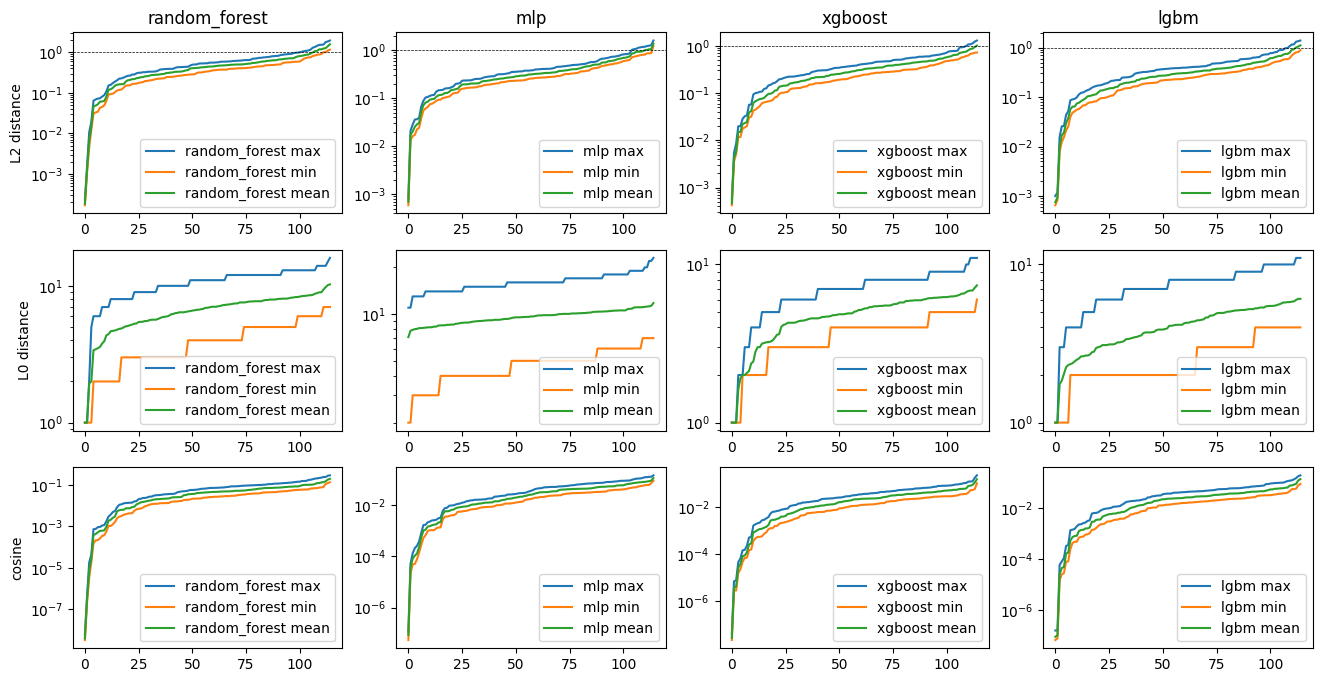

In [147]:
# to check plot the distances of the l2 metric for all the models
# use four subplots
fig, axs = plt.subplots(3,4,figsize=(16,8))
axs = axs.flatten()
for jj,k in enumerate(models.keys()):
    axs[jj].plot(sorted(np.array(all_stats_tmp[k]['distances']['l2']['max']) ),label=k+" max")
    axs[jj].plot(sorted(np.array(all_stats_tmp[k]['distances']['l2']['min']) ),label=k+" min")
    axs[jj].plot(sorted(np.array(all_stats_tmp[k]['distances']['l2']['mean']) ),label=k+" mean")
    # check the correct list
    axs[jj].axhline(1, color='black', linestyle='--', linewidth=0.5)
    axs[4+jj].plot(sorted(np.array(all_stats_tmp[k]['distances']['l0']['max']) ),label=k+" max")
    axs[4+jj].plot(sorted(np.array(all_stats_tmp[k]['distances']['l0']['min']) ),label=k+" min")
    axs[4+jj].plot(sorted(np.array(all_stats_tmp[k]['distances']['l0']['mean'])),label=k+" mean")

    axs[8+jj].plot(sorted(np.array(all_stats_tmp[k]['distances']['cosine']['max'])),label=k+" max")
    axs[8+jj].plot(sorted(np.array(all_stats_tmp[k]['distances']['cosine']['min'])),label=k+" min")
    axs[8+jj].plot(sorted(np.array(all_stats_tmp[k]['distances']['cosine']['mean'])),label=k+" mean")

    if jj== 0:
        axs[jj].set_ylabel("L2 distance")
        axs[4+jj].set_ylabel("L0 distance")
        axs[jj+8].set_ylabel("cosine")
    if jj>= 4:
        axs[4+jj].set_xlabel("Sample index")
        
    # assert that the cosine ones are in 0-2
    for mode in ['max','min','mean']:
        # assert len(all_stats[k]['distances']['cosine'][mode])>0, "No cosine distances found for model "+k
        
        minv = np.array(all_stats[k]['distances']['cosine'][mode]).min()
        maxv = np.array(all_stats[k]['distances']['cosine'][mode]).max()
        print("Checking cosine distances for",k,mode,"min value",minv,"max value",maxv)
        #assert ((np.array(all_stats[k]['distances']['cosine'][mode]) >= 0) & (np.array(all_stats[k]['distances']['cosine'][mode]) <= 2)).all()

    print(np.array(all_stats[k]['corrects']).sum()/len(all_stats[k]['corrects']))
    print(np.array(all_stats_test[k]['corrects']).sum()/len(all_stats_test[k]['corrects']))
    print(0.0==0,1.0==1)

    # set the legend and the title
    axs[jj].legend()
    axs[jj].set_title(k)

for ax in axs:
    ax.legend()
    #set yscale log
    ax.set_yscale("log")
    
plt.show()
    
    

In [148]:
# If I did an error, I have to remove the the whole list of distances for the models in the all_stats dictionary
# I will "re initialize" the list of distances for the models
'''
for k in ["mlp","lgbm","xgboost"]:
    all_stats[k]['distances'] = {
            metric: {
                'min': [],   # One value per sample
                'max': [],   # One value per samplea
                'mean': [],  # One value per sample, equal to min or max if only one value
                'std': [],   # One value per sample
            } for metric in metrics
        }
'''

'\nfor k in ["mlp","lgbm","xgboost"]:\n    all_stats[k][\'distances\'] = {\n            metric: {\n                \'min\': [],   # One value per sample\n                \'max\': [],   # One value per samplea\n                \'mean\': [],  # One value per sample, equal to min or max if only one value\n                \'std\': [],   # One value per sample\n            } for metric in metrics\n        }\n'

In [149]:
# check how many distancies are computed, i fear that I have confused the test and calibration set
for k in models.keys():
    print(k, "computed?",check_res(stats_dict = all_stats,k=k))
    print("\t","test?",check_res(stats_dict=all_stats_test,k=k))

(115 elements computed)
random_forest computed? False
(142 elements computed)
	 test? False
(115 elements computed)
mlp computed? False
(142 elements computed)
	 test? False
(115 elements computed)
xgboost computed? False
(142 elements computed)
	 test? False
(115 elements computed)
lgbm computed? False
(142 elements computed)
	 test? False


In [150]:
fname

'growing_spheres/breast_cancer_ranking.pkl'

In [151]:

if not utl.check_file_exists(fname):
    with open(fname, "wb") as f:
        pickle.dump(all_stats, f)
        print("dumped",fname)
else:
    print("File already exists",fname)

dumped growing_spheres/breast_cancer_ranking.pkl


In [152]:
fname_test

'growing_spheres/breast_cancer_ranking_test.pkl'

In [153]:

if not utl.check_file_exists(fname_test):
    with open(fname_test, "wb") as f:
        pickle.dump(all_stats_test, f)
        print("dumped",fname_test)
else:
    print("File already exists",fname_test)


dumped growing_spheres/breast_cancer_ranking_test.pkl


## End of File